In [1]:
import os
os.chdir("./..")

from PVDatasetWithHistory import PVDatasetWithHistory

ds = PVDatasetWithHistory(r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h", previous_days=5, split="test")

In [30]:
from models.ADRInspired import ADRInspired as ADR
from utils.config import load_config
import torch

config = load_config("./config/ADR.yaml")
ADR_fit = ADR(config)
ADR_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\ADR_fix\epoch=17-step=73728.ckpt", weights_only=False)["state_dict"])

<All keys matched successfully>

In [64]:
from models.PVUNet import PVUNet

config = load_config("./config/PVUNet.yaml")
PVUNet_fit = PVUNet(config)
PVUNet_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\GELU\epoch=4-step=2560.ckpt", weights_only=False)["state_dict"])
PVUNet_fit.eval()

PVUNet(
  (criterion): MSELoss()
  (model): UNet1D(
    (conv): ModuleDict(
      (1): Sequential(
        (0): Conv1d(47, 64, kernel_size=(3,), stride=(1,), padding=same)
        (1): ReLU()
        (2): Dropout1d(p=0.1, inplace=False)
        (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same)
        (4): ReLU()
        (5): Dropout1d(p=0.1, inplace=False)
      )
      (2): Sequential(
        (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=same)
        (1): ReLU()
        (2): Dropout1d(p=0.1, inplace=False)
        (3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=same)
        (4): ReLU()
        (5): Dropout1d(p=0.1, inplace=False)
      )
      (3): Sequential(
        (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=same)
        (1): ReLU()
        (2): Dropout1d(p=0.1, inplace=False)
        (3): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=same)
        (4): ReLU()
        (5): Dropout1d(p=0.1, inplace=False)
    

C:\Users\peter\AppData\Local\Temp\ipykernel_34848\1013131527.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)
C:\Users\peter\AppData\Local\Temp\ipykernel_34848\1013131527.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse_PVUNet = torch.nn.functional.mse_loss(torch.tensor(y_hat_PVUNet * 100), torch.tensor(y * 100))
C:\Users\peter\AppData\Local\Temp\ipykernel_34848\1013131527.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse_GHI = torch.nn.functional.mse_loss(torch.t

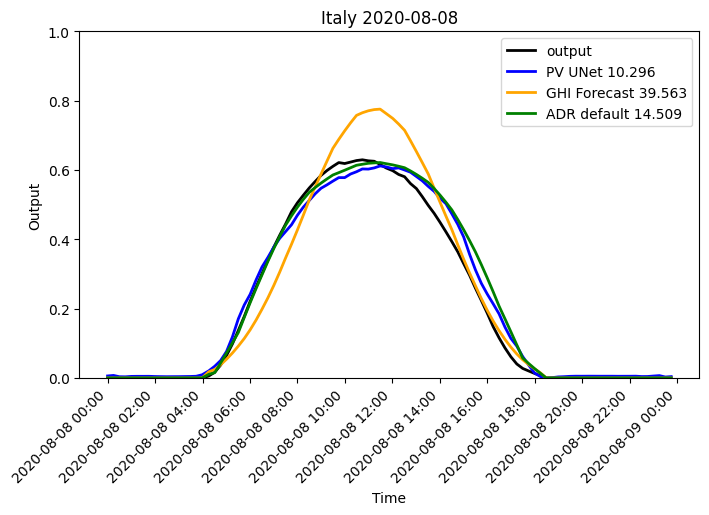

In [110]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from utils.normalize import normalize_inputs

import random

x, y, metadata = ds[random.randint(0, len(ds)-1)]
timestamps = x['unix_timestamps'].squeeze()
for key in list(x.keys()):
    x[key] = x[key].unsqueeze(0)
    # if key != 'ghi':
    #     del x[key]

for key in list(metadata.keys()):
    if isinstance(metadata[key], str):
        continue
    metadata[key] = torch.tensor(metadata[key]).unsqueeze(0)

x_copy = {k: v.clone() for k, v in x.items()}

y_hat = PVUNet_fit(x).squeeze()
y_hat_PVUNet = y_hat.detach().numpy()

y_hat_ADR = ADR_fit(x_copy, metadata)
y_hat_ADR = y_hat_ADR.detach().numpy()

ghi = x['ghi'].squeeze()

mse_PVUNet = torch.nn.functional.mse_loss(torch.tensor(y_hat_PVUNet * 100), torch.tensor(y * 100))
mse_GHI = torch.nn.functional.mse_loss(torch.tensor(ghi * 100), torch.tensor(y * 100))
mse_ADR = torch.nn.functional.mse_loss(torch.tensor(y_hat_ADR[0] * 100), torch.tensor(y * 100))

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(pd.to_datetime(timestamps, unit="s"), y, label="output", color="black", linewidth=2)
ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_PVUNet, label=f"PV UNet {mse_PVUNet:.3f}", color="blue", linewidth=2)
ax.plot(pd.to_datetime(timestamps, unit="s"), ghi, label=f"GHI Forecast {mse_GHI:.3f}", color="orange", linewidth=2)
ax.plot(pd.to_datetime(timestamps, unit="s"), y_hat_ADR[0], label=f"ADR default {mse_ADR:.3f}", color="green", linewidth=2)
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0,1)
plt.title(f"{metadata['country']} {metadata['date']}")
plt.show()